In [1]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import pickle  # para guardar objetos shapely/polígonos
from shapely.geometry import Polygon


In [2]:
# Paths relativos
BASE_DIR = os.path.abspath("..")                  # raíz del repo
DATA_RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
DATA_PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
SHAPES_DIR = os.path.join(DATA_RAW_DIR, "shapes") # aquí están los shapefiles

In [3]:
# Asegurar que la carpeta processed exista
os.makedirs(DATA_PROCESSED_DIR, exist_ok=True)
print("Setup listo ✅")

Setup listo ✅


In [4]:
# --- 1️⃣ CARGAR SHAPES ---
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")
bbii_shp_path = os.path.join(SHAPES_DIR, "Burdwood_2.shp")

In [5]:
bbi_shape = gpd.read_file(bbi_shp_path)
bbii_shape = gpd.read_file(bbii_shp_path)

C:\Users\gisel\AppData\Local\Temp\ipykernel_28592\3828350713.py:5: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\gisel\AppData\Local\Temp\ipykernel_28592\3828350713.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


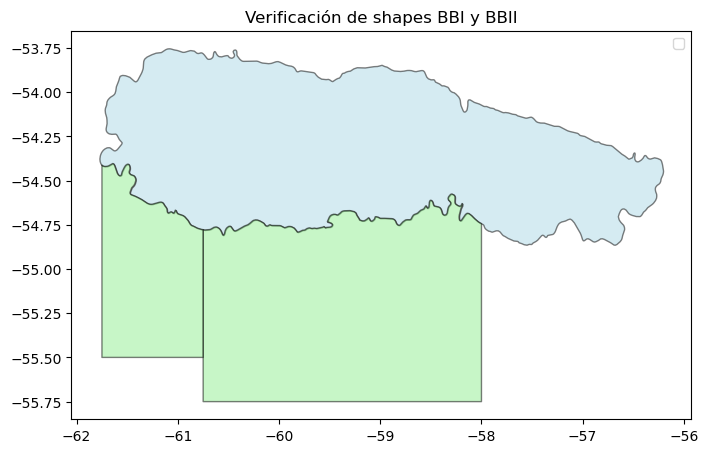

In [6]:
fig, ax = plt.subplots(figsize=(8,8))
bbi_shape.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5, label="BBI")
bbii_shape.plot(ax=ax, color="lightgreen", edgecolor="black", alpha=0.5, label="BBII")
ax.set_title("Verificación de shapes BBI y BBII")
ax.legend()
plt.show()


C:\Users\gisel\AppData\Local\Temp\ipykernel_28592\2178318223.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bbii_union = bbii_shape.unary_union   # devuelve un MultiPolygon o Polygon unificado
C:\Users\gisel\AppData\Local\Temp\ipykernel_28592\2178318223.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\gisel\AppData\Local\Temp\ipykernel_28592\2178318223.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


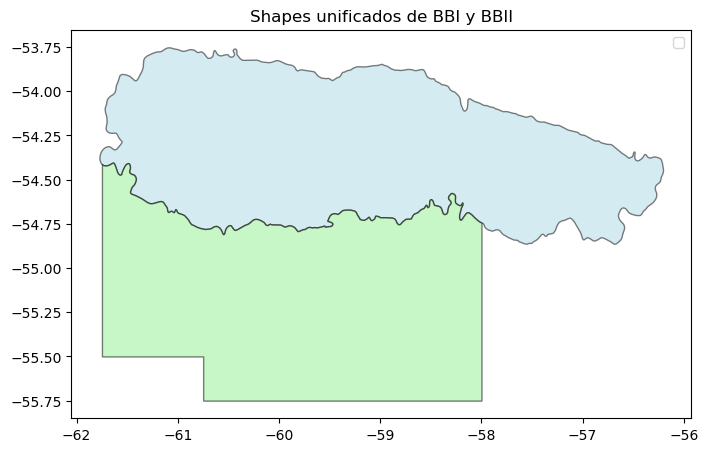

In [7]:
# --- 1️⃣ CARGAR SHAPES ---
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")   # BBI
bbii_shp_path = os.path.join(SHAPES_DIR, "Burdwood_2.shp")       # BBII (dos polígonos)

bbi_shape = gpd.read_file(bbi_shp_path)
bbii_shape = gpd.read_file(bbii_shp_path)

# --- 2️⃣ UNIFICAR POLÍGONOS DE BBII ---
# Si el shapefile tiene más de un polígono, los combinamos en uno solo
bbii_union = bbii_shape.unary_union   # devuelve un MultiPolygon o Polygon unificado

# Opcional: guardar como nuevo GeoDataFrame para manejarlo igual que bbi
bbii_shape_union = gpd.GeoDataFrame({"name": ["BBII"]}, geometry=[bbii_union], crs=bbii_shape.crs)

# --- 3️⃣ GRAFICAR ---
fig, ax = plt.subplots(figsize=(8,8))

bbi_shape.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5, label="BBI")
bbii_shape_union.plot(ax=ax, color="lightgreen", edgecolor="black", alpha=0.5, label="BBII (unido)")

ax.set_title("Shapes unificados de BBI y BBII")
ax.legend()
plt.show()


   FID                                           geometry
0    0  POLYGON ((-58 -55.75, -60.75 -55.75, -60.75 -5...


<Axes: >

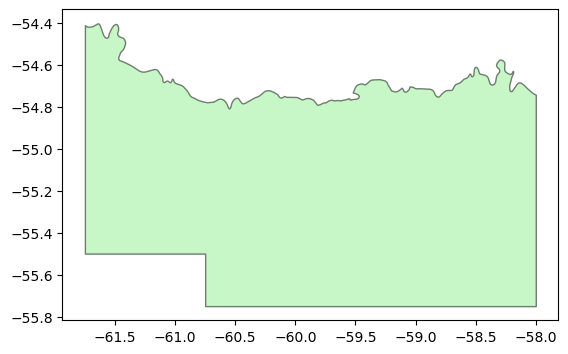

In [8]:
bbii_union_path = os.path.join(SHAPES_DIR, "BBII_unificado.shp")

bbii_shape_union = gpd.read_file(bbii_union_path)
print(bbii_shape_union)
bbii_shape_union.plot(edgecolor='black', facecolor='lightgreen', alpha=0.5)

In [9]:
print(os.getcwd())


C:\Users\gisel\BB_stress_paper\notebooks


### Guardamos los shapes

In [10]:
from shapely.ops import unary_union

# --- 1️⃣ Unificar polígonos de BBII ---
# Si bbii_shape tiene más de un polígono
bbii_unificado = unary_union(bbii_shape.geometry)

# Crear un GeoDataFrame nuevo
import geopandas as gpd
bbii_gdf = gpd.GeoDataFrame(geometry=[bbii_unificado], crs=bbii_shape.crs)

# --- 2️⃣ Guardar el nuevo shapefile ---
output_path = "../data/raw/shapes/BBII_unificado.shp"
bbii_gdf.to_file(output_path)

print(f"Shape unificado guardado en: {output_path}")

Shape unificado guardado en: ../data/raw/shapes/BBII_unificado.shp


In [7]:
import xarray as xr


Batimetria

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [13]:
# NetCDF de batimetría
gebco_path = os.path.join(SHAPES_DIR, "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc")

# Shapes de BBI y BBII
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")
bbii_shp_path = os.path.join(SHAPES_DIR, "Burdwood_2_unificado.shp")

In [15]:
ds = xr.open_dataset(gebco_path)
bath = ds['elevation']


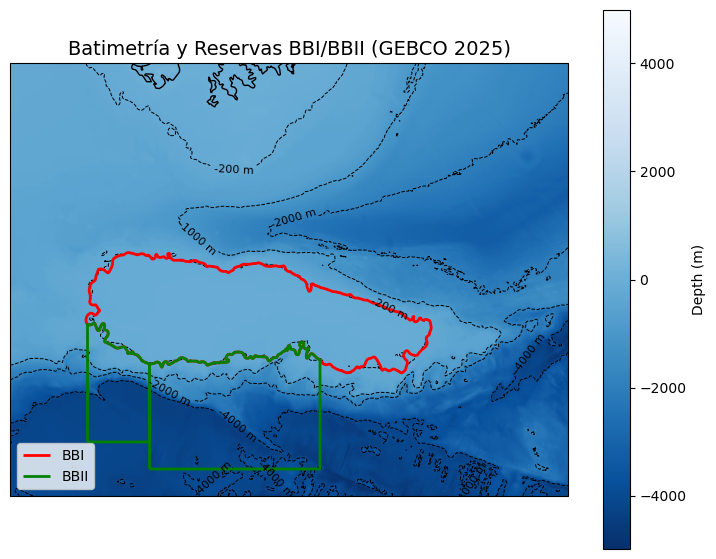

In [16]:
# --- 3️⃣ Crear figura ---
plt.figure(figsize=(9,7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Batimetría
bath.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    cbar_kwargs={'label': 'Depth (m)'}
)

# Isóbatas (200, 1000, 2000, 4000 m)
contours = bath.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(),
    levels=[-200, -1000, -2000, -4000],
    colors='k', linewidths=0.7
)
ax.clabel(contours, fmt='%d m', fontsize=8)

# --- 4️⃣ Agregar shapes ---
bbi_shape.boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="BBI")
bbii_shape.boundary.plot(ax=ax, edgecolor="green", linewidth=2, label="BBII")

# --- 5️⃣ Extras ---
ax.coastlines(resolution="10m", color="black", linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.legend(loc="lower left")
plt.title("Batimetría y Reservas BBI/BBII (GEBCO 2025)", fontsize=14)

plt.show()

CORTANDO LOS DATOS CON LA FORMA DE LOS SHAPES

In [17]:
# === Cargar shapes ===
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")
bbii_shp_path = os.path.join(SHAPES_DIR, "BBII_unificado.shp")

bbi = gpd.read_file(bbi_shp_path)
bbii = gpd.read_file(bbii_shp_path)

# --- Función para recortar por polígono ---
def mask_polygon(ds, gdf):
    """
    Recorta un Dataset de xarray con un polígono de GeoDataFrame.
    Compatible con datasets 3D o 4D (time, depth, lat, lon).
    """
    # Unir polígonos si hay más de uno
    polygon = gdf.geometry.union_all() if hasattr(gdf.geometry, "union_all") else gdf.geometry.unary_union
    
    # Obtener coordenadas
    lon, lat = np.meshgrid(ds['longitude'], ds['latitude'])
    points = gpd.GeoSeries(gpd.points_from_xy(lon.ravel(), lat.ravel()), crs="EPSG:4326")
    
    # Crear máscara 2D (lat, lon)
    mask2d = points.within(polygon).values.reshape(lat.shape)
    
    # Expandir máscara según dimensiones
    if 'time' in ds.dims:
        mask = np.broadcast_to(mask2d, (ds.sizes['time'], ds.sizes['latitude'], ds.sizes['longitude']))
        mask = xr.DataArray(mask, dims=('time', 'latitude', 'longitude'))
    elif 'depth' in ds.dims and 'time' in ds.dims:
        mask = np.broadcast_to(mask2d, (ds.sizes['time'], ds.sizes['depth'], ds.sizes['latitude'], ds.sizes['longitude']))
        mask = xr.DataArray(mask, dims=('time', 'depth', 'latitude', 'longitude'))
    else:
        mask = xr.DataArray(mask2d, dims=('latitude', 'longitude'))
    
    return ds.where(mask)

In [18]:
import numpy as np


In [ ]:
# === SST ===
sst_path = os.path.join(DATA_RAW_DIR, "SST", "sst_combined.nc")
ds_sst = xr.open_dataset(sst_path)

# Recortes por shape
ds_sst_bbi = mask_polygon(ds_sst, bbi)
ds_sst_bbii = mask_polygon(ds_sst, bbii)

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "SST")
os.makedirs(out_dir, exist_ok=True)

ds_sst_bbi.to_netcdf(os.path.join(out_dir, "sst_BBI.nc"))
ds_sst_bbii.to_netcdf(os.path.join(out_dir, "sst_BBII.nc"))
ds_sst.to_netcdf(os.path.join(out_dir, "sst_bbox.nc"))  # el recorte cuadrado original

In [19]:
# === pH ===

ph_path = os.path.join(DATA_RAW_DIR, "ph", "cmems_obs-mob_glo_bgc-car_my_irr-i_1769029168109.nc")
ds_ph = xr.open_dataset(ph_path)

# Recortes por shape
ds_ph_bbi = mask_polygon(ds_ph, bbi)
ds_ph_bbii = mask_polygon(ds_ph, bbii)

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "pH")
os.makedirs(out_dir, exist_ok=True)

#pongo nombres temporales pq me da error al guardar
tmp_bbi = os.path.join(out_dir, "tmp_ph_BBI.nc")
tmp_bbii = os.path.join(out_dir, "tmp_ph_BBII.nc")
tmp_bbox = os.path.join(out_dir, "tmp_ph_bbox.nc")

ds_ph_bbi.to_netcdf(tmp_bbi, engine="scipy")
ds_ph_bbii.to_netcdf(tmp_bbii, engine="scipy")
ds_ph.to_netcdf(tmp_bbox, engine="scipy")


In [ ]:
# === O2 Hindcast ===
o2_hindcast_path = os.path.join(DATA_RAW_DIR, "Oxigeno", "cmems_mod_glo_bgc_my_0.25deg_P1M-m_1757960017296.nc")
ds_o2 = xr.open_dataset(o2_hindcast_path)

# Recortes por shape
ds_o2_bbi = mask_polygon(ds_o2, bbi)
ds_o2_bbii = mask_polygon(ds_o2, bbii)

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "O2")
os.makedirs(out_dir, exist_ok=True)

ds_o2_bbi.to_netcdf(os.path.join(out_dir, "o2_hindcast_BBI.nc"))
ds_o2_bbii.to_netcdf(os.path.join(out_dir, "o2_hindcast_BBII.nc"))
ds_o2.to_netcdf(os.path.join(out_dir, "o2_hindcast_bbox.nc"))

In [ ]:
import pandas as pd


In [ ]:
# === O2 Observaciones (GLODAP) ===
glodap_path = os.path.join(DATA_RAW_DIR, "Oxigeno", "cmems_obs-ins_glo_bgc-car_my_glodap-obs_irr_1757964471340.csv")

df_glodap = pd.read_csv(glodap_path, comment="#")
gdf_glodap = gpd.GeoDataFrame(df_glodap, geometry=gpd.points_from_xy(df_glodap.longitude, df_glodap.latitude), crs="EPSG:4326")

# Recortes por shape
gdf_glodap_bbi = gdf_glodap[gdf_glodap.within(bbi.geometry.unary_union)]
gdf_glodap_bbii = gdf_glodap[gdf_glodap.within(bbii.geometry.unary_union)]

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "O2")
os.makedirs(out_dir, exist_ok=True)

gdf_glodap_bbi.to_csv(os.path.join(out_dir, "o2_glodap_BBI.csv"), index=False)
gdf_glodap_bbii.to_csv(os.path.join(out_dir, "o2_glodap_BBII.csv"), index=False)
gdf_glodap.to_csv(os.path.join(out_dir, "o2_glodap_bbox.csv"), index=False)

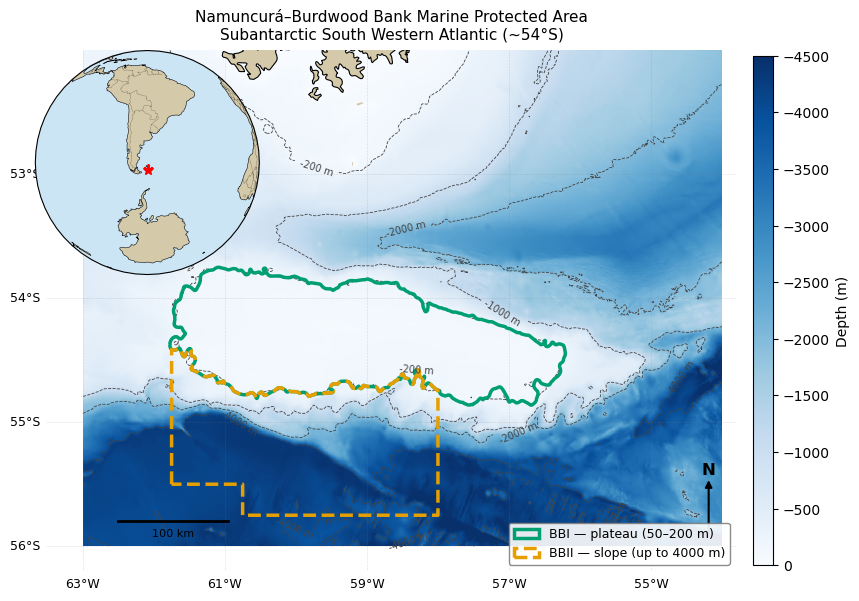

✅ Fig1_study_area.png guardada


In [24]:
import os
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.ops import unary_union
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

BASE_DIR   = os.path.abspath("..")
SHAPES_DIR = os.path.join(BASE_DIR, "data", "raw", "shapes")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# =============================================================================
# Cargar datos
# =============================================================================

gebco_path  = os.path.join(SHAPES_DIR, "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc")
bbi_shape   = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))

ds   = xr.open_dataset(gebco_path)
bath = ds["elevation"]

# Colores daltónico-friendly (Wong 2011)
COLOR_BBI  = "#009E73"
COLOR_BBII = "#E69F00"

# =============================================================================
# Figura principal
# =============================================================================

proj = ccrs.PlateCarree()
fig  = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor("white")
fig.patch.set_alpha(0)
ax   = fig.add_subplot(1, 1, 1, projection=proj)

# Extent
EXTENT = [-63.5, -53.8, -56.2, -52.0]
ax.set_extent(EXTENT, crs=proj)

# --- Batimetría ---
bath_plot = bath.plot(
    ax=ax, transform=proj,
    cmap="Blues_r",
    vmin=-4500, vmax=0,
    add_colorbar=False,
    add_labels=False,
)

# Colorbar
cbar = plt.colorbar(bath_plot, ax=ax, orientation="vertical",
                    pad=0.02, shrink=0.7, aspect=25)
cbar.set_label("Depth (m)", fontsize=10)
cbar.ax.invert_yaxis()

# --- Isóbatas ---
lons_g = bath.lon.values if "lon" in bath.coords else bath.longitude.values
lats_g = bath.lat.values if "lat" in bath.coords else bath.latitude.values
cs = ax.contour(lons_g, lats_g, bath.values,
                levels=[-4000, -2000, -1000, -200],
                colors=["#444444"], linewidths=[0.6],
                transform=proj)
ax.clabel(cs, fmt="%d m", fontsize=7, inline=True)

# --- Shapes BBI y BBII ---
bbi_shape.boundary.plot(ax=ax, transform=proj,
                         edgecolor=COLOR_BBI, linewidth=2.5,
                         label="BBI (plateau)")
bbii_shape.boundary.plot(ax=ax, transform=proj,
                          edgecolor=COLOR_BBII, linewidth=2.5,
                          linestyle="--", label="BBII (slope)")

# --- Tierra y costas ---
ax.add_feature(cfeature.LAND, facecolor="#d4c9a8", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5, zorder=4)

# --- Grilla de coordenadas ---
gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                   color="gray", alpha=0.5, linestyle=":")
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator([-63, -61, -59, -57, -55])
gl.ylocator = mticker.FixedLocator([-56, -55, -54, -53, -52])
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

# --- Flecha de norte ---
ax.annotate("N", xy=(0.96, 0.18), xycoords="axes fraction",
            fontsize=12, fontweight="bold", ha="center", va="bottom")
ax.annotate("", xy=(0.96, 0.18), xytext=(0.96, 0.06),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))

# --- Escala gráfica (aprox 100 km) ---
# A ~54°S, 1° de longitud ≈ 65 km → 1.54° ≈ 100 km
scale_lon_start = -62.5
scale_lon_end   = scale_lon_start + 1.54
scale_lat       = -55.8
ax.plot([scale_lon_start, scale_lon_end], [scale_lat, scale_lat],
        color="black", lw=2, transform=proj, zorder=5)
ax.text((scale_lon_start + scale_lon_end) / 2, scale_lat - 0.12,
        "100 km", ha="center", fontsize=8, transform=proj, zorder=5)

# --- Leyenda ---
patch_bbi  = mpatches.Patch(edgecolor=COLOR_BBI,  facecolor="none",
                              linewidth=2.5, label="BBI — plateau (50–200 m)")
patch_bbii = mpatches.Patch(edgecolor=COLOR_BBII, facecolor="none",
                              linewidth=2.5, linestyle="--",
                              label="BBII — slope (up to 4000 m)")
ax.legend(handles=[patch_bbi, patch_bbii],
          loc="lower right", fontsize=9,
          framealpha=0.9, edgecolor="gray")

# --- Título ---
ax.set_title(
    "Namuncurá–Burdwood Bank Marine Protected Area\n"
    "Subantarctic South Western Atlantic (~54°S)",
    fontsize=11, pad=8
)

# =============================================================================
# Mapa de contexto global (inset)
# =============================================================================

ax_inset = fig.add_axes([0.01, 0.55, 0.28, 0.28],
                         projection=ccrs.Orthographic(
                             central_longitude=-60, central_latitude=-50))
ax_inset.set_global()
ax_inset.add_feature(cfeature.LAND,      facecolor="#d4c9a8")
ax_inset.add_feature(cfeature.OCEAN,     facecolor="#cce5f5")
ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax_inset.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")
ax_inset.plot(-59, -54, marker="*", color="red",
              markersize=8, transform=proj, zorder=5)
for spine in ax_inset.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)

# =============================================================================
# Guardar
# =============================================================================

plt.subplots_adjust(left=0.05, right=0.88, top=0.96, bottom=0.05)
ax.spines['geo'].set_edgecolor("none")
plt.savefig(os.path.join(FIGURES_DIR, "Fig1_study_area.png"),
            dpi=300, facecolor=fig.get_facecolor(), edgecolor="none")
plt.show()

print("✅ Fig1_study_area.png guardada")